In [1]:
import sqlite3
import pandas as pd
import numpy as np
from tqdm import tqdm
import json

In [ ]:
SQLITE_PATH = "/content/drive/MyDrive/CAP5771-abbhinav.sriram/dev_notebooks/dev_ai_articles_full.sqlite"


dev_articles = "articles"
DEV_COLUMN_CONFIG = {
    "id": "id",           # primary key column
    "title": "title",     # article title column
    "body": "body_text",       # article body/content column (set to None if not available)
}

hashnode_articles = "hashnode_articles"
HASHNODE_COLUMN_CONFIG = {
    "id": "id",           # primary key column
	"title": "title",     # article title column
	"body": "body",       # article body/content column (set to None if not available)
}

# How much body text to use (tokens are expensive; first 500 chars is usually enough)
BODY_PREVIEW_CHARS = 1500

# Batch size for zero-shot classification (lower if you run out of RAM)
CLASSIFICATION_BATCH_SIZE = 32

In [3]:
conn = sqlite3.connect(SQLITE_PATH)
cursor = conn.cursor()

In [ ]:
id_col = DEV_COLUMN_CONFIG["id"]
title_col = DEV_COLUMN_CONFIG["title"]
body_col = DEV_COLUMN_CONFIG["body"]
		
query = f"SELECT {id_col}, {title_col}, {body_col} FROM {dev_articles}"

df = pd.read_sql_query(query, conn)


hashnode_df = pd.read_sql_query(f"SELECT {id_col}, {title_col}, {body_col} FROM {hashnode_articles}", conn)




In [5]:
df

,id,title,body_text
0,142249,The Distressed Code Review,title: The Distressed Code Review published: t...
1,198370,Avoid These Terrible Web Notifications Mistake...,This article is a brief introduction to some b...
2,385335,DNS Explained. Resolution,This is an article in the DNS Explained. serie...
3,423055,You don't need a library for state machines,title: You don't need a library for state mach...
4,441453,Data Engineering Series #3: Apache Airflow - t...,Why such attention towards Airflow ? Interest ...
...,...,...,...
3019,3363277,Hardware Hacking 101 Village - Post-Mortem,title: Hardware Hacking 101 Village Post Morte...
3020,3363288,FE/BE - Unite Them!,tl;dr; Teams should agree upon and understand ...
3021,3363939,Announcing the Colab MCP Server: Connect Any A...,When you’re prototyping locally with AI agents...
3022,3364128,I Built a Claude Code Agent That Doesn't Need ...,title: I Built a Claude Code Agent That Doesn'...


In [6]:
hashnode_df

,id,title,body_text
0,69c4b8a8efeaf33e6b3675be,MonALISA : A Distributed Monitoring Service Ar...,Adaptive Monitoring for Large Scale Grids: a S...
1,69c4bd952d879655ece508e5,The Sweet Spot of AI Orchestration: From AWS L...,The Sweet Spot of AI Orchestration: From AWS L...
2,69c4aaa5bbdb1bc33f100e25,"45 Claude Code Hooks for Code Quality, Securit...",45 Claude Code Hooks I Use to Automate Code Qu...
3,69c4a9faaed4ec64674bd0db,Claude Code Channels: Set Up a 24/7 AI Agent v...,Claude Code Channels Just Dropped — Here's How...
4,69c4a88eea32df99834d3704,I Built My Own OpenClaw Alternative With Claud...,I Built My Own OpenClaw Alternative With Claud...
...,...,...,...
22643,69a85632e55311e40f0eeb63,Building an AI-Powered Hospital Infection Inte...,A Case Study from CODE:AUTOMATA Ver 2.1 Hackat...
22644,69a8580ae55311e40f0fd641,You don't know your AI stack.,AI tooling has no supply chain. No audit trail...
22645,69a8589de55311e40f1023c3,How AI Is Changing Software Architecture Planning,Most AI conversations in software focus on cod...
22646,69a6cd5c75d7a0f10015ca0d,How to Run and Customize LLMs Locally with Ollama,In the long history of technological innovatio...


In [7]:
df_all = pd.concat([df, hashnode_df], ignore_index=True)

In [8]:
df_all

,id,title,body_text
0,142249,The Distressed Code Review,title: The Distressed Code Review published: t...
1,198370,Avoid These Terrible Web Notifications Mistake...,This article is a brief introduction to some b...
2,385335,DNS Explained. Resolution,This is an article in the DNS Explained. serie...
3,423055,You don't need a library for state machines,title: You don't need a library for state mach...
4,441453,Data Engineering Series #3: Apache Airflow - t...,Why such attention towards Airflow ? Interest ...
...,...,...,...
25667,69a85632e55311e40f0eeb63,Building an AI-Powered Hospital Infection Inte...,A Case Study from CODE:AUTOMATA Ver 2.1 Hackat...
25668,69a8580ae55311e40f0fd641,You don't know your AI stack.,AI tooling has no supply chain. No audit trail...
25669,69a8589de55311e40f1023c3,How AI Is Changing Software Architecture Planning,Most AI conversations in software focus on cod...
25670,69a6cd5c75d7a0f10015ca0d,How to Run and Customize LLMs Locally with Ollama,In the long history of technological innovatio...


Now that dfs are combined, we can start clustering

In [9]:
df_all["combined_text"] = (
	df_all[title_col].fillna("") + " " +
	df_all[body_col].fillna("").str[:BODY_PREVIEW_CHARS]
).str.strip()

In [10]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")  # ~80MB, fast, good quality

texts = df_all["combined_text"].tolist()
embeddings = model.encode(
	texts,
	batch_size=64,
	show_progress_bar=True,
	convert_to_numpy=True,
)
print(f"✅ Embeddings shape: {embeddings.shape}")


embeddings

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/402 [00:00<?, ?it/s]

✅ Embeddings shape: (25672, 384)


array([[-0.03045664, -0.02122167, -0.02453274, ..., -0.03061732,
         0.06307959,  0.06322037],
       [-0.0391487 , -0.03178785,  0.00176705, ..., -0.0143971 ,
        -0.03717555,  0.06547666],
       [-0.01395679, -0.05800174,  0.05732981, ...,  0.06991707,
        -0.03069574,  0.03327539],
       ...,
       [ 0.02045865,  0.05308983,  0.05026496, ...,  0.00267063,
        -0.02624445, -0.02031038],
       [ 0.02364531, -0.07605476,  0.02792239, ...,  0.04681318,
        -0.05939622, -0.01434456],
       [-0.04372466, -0.05249125, -0.02987418, ..., -0.06269559,
         0.07843874, -0.0632586 ]], dtype=float32)

In [11]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import PCA

n_clusters = 10


# Reduce dims first for speed
pca = PCA(n_components=50, random_state=42)
reduced = pca.fit_transform(embeddings)

km = MiniBatchKMeans(n_clusters=n_clusters, random_state=42, n_init=3)
labels = km.fit_predict(reduced)

unique, counts = np.unique(labels, return_counts=True)
for u, c in zip(unique, counts):
	print(f"   Cluster {u:2d}: {c:,} articles")


labels

   Cluster  0: 3,212 articles
   Cluster  1: 2,580 articles
   Cluster  2: 3,939 articles
   Cluster  3: 2,989 articles
   Cluster  4: 2,031 articles
   Cluster  5: 1,992 articles
   Cluster  6: 2,437 articles
   Cluster  7: 2,368 articles
   Cluster  8: 2,409 articles
   Cluster  9: 1,715 articles


array([2, 2, 2, ..., 3, 0, 4], dtype=int32)

In [20]:
from sklearn.preprocessing import normalize

# Define the target theme as a natural language query
TARGET_THEME = "AI automation impact on society, environment, law, and jobs"

from sentence_transformers import SentenceTransformer
_model = SentenceTransformer("all-MiniLM-L6-v2")
theme_embedding = _model.encode([TARGET_THEME], convert_to_numpy=True)

# Compute cluster centroids in original embedding space
n_c = n_clusters
centroids = np.array([
    embeddings[labels == c].mean(axis=0) for c in range(n_c)
])

# Cosine similarity between theme and each centroid
norm_centroids = normalize(centroids)
norm_theme = normalize(theme_embedding)
cosine_sims = (norm_centroids @ norm_theme.T).flatten()

# Rank clusters by similarity
ranked = sorted(enumerate(cosine_sims), key=lambda x: -x[1])
print("Cluster similarity to target theme:")
for cluster_id, sim in ranked:
    print(f"  Cluster {cluster_id:2d}: {sim:.4f}  ({counts[cluster_id]:,} articles)")

# Auto-select top clusters above a similarity threshold
SIM_THRESHOLD = 0.5
relevant_clusters = [c for c, s in ranked if s >= SIM_THRESHOLD]
print(f"\nAuto-selected clusters: {relevant_clusters}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Cluster similarity to target theme:
  Cluster  3: 0.6670  (2,989 articles)
  Cluster  6: 0.5966  (2,437 articles)
  Cluster  5: 0.5281  (1,992 articles)
  Cluster  7: 0.4840  (2,368 articles)
  Cluster  0: 0.4358  (3,212 articles)
  Cluster  4: 0.3529  (2,031 articles)
  Cluster  1: 0.2947  (2,580 articles)
  Cluster  2: 0.2642  (3,939 articles)
  Cluster  9: 0.1981  (1,715 articles)
  Cluster  8: 0.1280  (2,409 articles)

Auto-selected clusters: [3, 6, 5]


In [22]:
df_all_copy = df_all.copy()
df_all_copy["cluster"] = labels

# Print sample articles from each selected cluster for sanity check
n_samples = 10
for cluster_id in relevant_clusters:
    samples = df_all_copy[df_all_copy["cluster"] == cluster_id]["combined_text"].head(n_samples).tolist()
    print(f"\n── Cluster {cluster_id} (sim={cosine_sims[cluster_id]:.3f}) ──")
    for s in samples:
        print(f"  • {s[:120]}")


── Cluster 3 (sim=0.667) ──
  • 12 Important Software Testing Trends for 2021 You Need to Know Software testing is making many moves. From AI to ML, it 
  • Another 8th of March, yet we are not still there! Where are we about equality in tech in 2021? Aren't we still there yet
  • Top Automation Testing Trends To Look Out In 2021 Back in the old days, software testing was just about finding errors i
  • Moving Forward; A Follow-Up to the Cautionary Tale for Open Source Devs Following up from recent events with good news a
  • How Silicone Valley Betrayed The People Remember the old days when the internet used to be the only escape you had to ru
  • AI and Frontend Development: A Match Made in Tech Heaven? AI and Frontend Development: A Match Made in Tech Heaven? Fron
  • AI and Ethics [Chapter 1] I recently purchased The Oxford Handbook of Ethics of AI. This is a 900 page monster book...wi
  • Idea: Using Decentralized Identities to Fight AI Threats and Shape Internet 3.0 With the rap

In [27]:

# Filtered df with only relevant clusters
df_filtered = df_all_copy[df_all_copy["cluster"].isin(relevant_clusters)].copy()

print(f"Original articles: {len(df_all_copy)}")
print(f"Filtered articles: {len(df_filtered)}")
print(f"Removed: {len(df_all_copy) - len(df_filtered)}")


Original articles: 25672
Filtered articles: 7418
Removed: 18254


In [28]:
df_filtered

,id,title,body_text,combined_text,cluster
50,547819,Entropy for developers,Entropy) is a mathematical concept which quant...,Entropy for developers Entropy) is a mathemati...,5
396,604165,12 Important Software Testing Trends for 2021 ...,Software testing is making many moves. From AI...,12 Important Software Testing Trends for 2021 ...,3
497,624875,Machine Learning in SQL Style (Part-1),"Machine learning(ML) is everywhere, you look a...",Machine Learning in SQL Style (Part-1) Machine...,5
508,628993,"Another 8th of March, yet we are not still there!",Where are we about equality in tech in 2021? A...,"Another 8th of March, yet we are not still the...",3
588,645109,Top Automation Testing Trends To Look Out In 2021,"Back in the old days, software testing was jus...",Top Automation Testing Trends To Look Out In 2...,3
...,...,...,...,...,...
25664,699ec8f107208e46d780c4ea,From Assistant to Actor: How AI Agents are Run...,The landscape of digital marketing has shifted...,From Assistant to Actor: How AI Agents are Run...,6
25665,69a889213b896f7ad6749182,I Thought AI Made Me Faster. My Metrics Disagr...,"Friday, 4:47 PM. A PR lands in the repo with a...",I Thought AI Made Me Faster. My Metrics Disagr...,3
25667,69a85632e55311e40f0eeb63,Building an AI-Powered Hospital Infection Inte...,A Case Study from CODE:AUTOMATA Ver 2.1 Hackat...,Building an AI-Powered Hospital Infection Inte...,5
25668,69a8580ae55311e40f0fd641,You don't know your AI stack.,AI tooling has no supply chain. No audit trail...,You don't know your AI stack. AI tooling has n...,3


Zero-shot classification

In [29]:
CANDIDATE_LABELS_PRIMARY = [
    "a coding tutorial, technical guide, or software implementation walkthrough with little discussion of societal implications",
    "an opinion piece, analysis, or commentary on AI's consequences for society, law, environment, or ethics",
]


CANDIDATE_LABELS_SECONDARY = [
    "discussion of the environmental impact or energy consumption of AI",
    "discussion of legal, regulatory, or policy issues related to AI",
    "discussion of ethical concerns, bias, or fairness in AI systems",
    "discussion of AI's impact on jobs, employment, or the economy",
    "discussion of AI in geopolitics, international competition, or national security",
    "discussion of how AI is portrayed in media or public opinion",
    "discussion of AI safety, alignment, or existential risks",
]


In [30]:
def classify_batch(pipe, texts, candidate_labels, threshold=0.5):
    results = pipe(texts, candidate_labels, multi_label=True)
    if isinstance(results, dict):
        results = [results]
    
    output = []
    for r in results:
        labels_scores = [
            (label, score)
            for label, score in zip(r["labels"], r["scores"])
            if score >= threshold
        ]
        output.append(labels_scores)
    
    return output

In [31]:
from transformers import pipeline

pipe = pipeline(
	"zero-shot-classification",
	model="facebook/bart-large-mnli",
	device=0,  # CPU; change to 0 if you have a CUDA GPU
)

texts = df_filtered["combined_text"].tolist()
primary_labels = []
primary_scores = []


for i in tqdm(range(0, len(texts), CLASSIFICATION_BATCH_SIZE)):
    batch = texts[i : i + CLASSIFICATION_BATCH_SIZE]
    results = classify_batch(pipe, batch, CANDIDATE_LABELS_PRIMARY, threshold=0.0)

    for r in results:
        # r is like: [("technical ...", 0.88), ("non-technical ...", 0.12)]
        if not r:
            primary_labels.append("UNSURE")
            primary_scores.append(0.0)
            continue
        if r[0][1] < 0.5:  # If the top label is below threshold or less confident than second, mark as UNSURE
            primary_labels.append("UNSURE")
            primary_scores.append(0.0)
            continue
        top_label, top_score = r[0]
        is_technical = "technical" in top_label.lower()
        primary_labels.append("TECHNICAL" if is_technical else "NON_TECHNICAL")
        primary_scores.append(float(top_score))
df_filtered.loc[df_filtered.index[:30], "primary_label"] = primary_labels[:30]
df_filtered.loc[df_filtered.index[:30], "primary_score"] = primary_scores[:30]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

100%|██████████| 232/232 [24:48<00:00,  6.41s/it]


In [32]:
# # Sub-classify only the non-technical ones
# non_tech_mask = df_filtered["primary_label"] == "NON_TECHNICAL"
# non_tech_texts = df_filtered.loc[non_tech_mask, "combined_text"].tolist()
# non_tech_indices = df_filtered.index[non_tech_mask].tolist()

# print(f"\n   Found {len(non_tech_texts):,} non-technical articles")
# print("   Step 2/2: Sub-categorizing non-technical articles...")

# secondary_labels = [""] * len(df_filtered)
# secondary_scores = [0.0] * len(df_filtered)

# for i, (idx, text) in enumerate(tqdm(zip(non_tech_indices, non_tech_texts))):
# 	result = classify_batch(pipe, [text], CANDIDATE_LABELS_SECONDARY)[0]
# 	secondary_labels[idx] = result["label"]
# 	secondary_scores[idx] = result["score"]

# df_filtered["secondary_label"] = secondary_labels
# df_filtered["secondary_score"] = secondary_scores

# print("✅ Classification complete")

In [33]:
import sqlite3

conn = sqlite3.connect("dev_ai_articles_full.sqlite")
df_filtered.to_sql("topic labeled articles", conn, if_exists="replace", index=False)
conn.close()

In [34]:
# # Sub-classify only the non-technical ones
# non_tech_mask = df_filtered["primary_label"] != "TECHNICAL"
# non_tech_texts = df_filtered.loc[non_tech_mask, "combined_text"].tolist()
# non_tech_indices = df_filtered.index[non_tech_mask].tolist()

# print(f"\n   Found {len(non_tech_texts):,} non-technical articles")
# print("   Step 2/2: Sub-categorizing non-technical articles...")

# secondary_labels = [""] * len(df_filtered)
# secondary_scores = [0.0] * len(df_filtered)

# for i in tqdm(range(0, len(non_tech_texts), CLASSIFICATION_BATCH_SIZE)):
#     batch_texts = non_tech_texts[i : i + CLASSIFICATION_BATCH_SIZE]
#     batch_indices = non_tech_indices[i : i + CLASSIFICATION_BATCH_SIZE]

#     results = classify_batch(
#         pipe,
#         batch_texts,
#         CANDIDATE_LABELS_SECONDARY,
#         threshold=0.0
#     )

#     for idx, r in zip(batch_indices, results):
#         if not r:
#             secondary_labels[idx] = "UNSURE"
#             secondary_scores[idx] = 0.0
#             continue
#         if r[0][1] < 0.7:  # If the top label is below threshold or less confident than second, mark as UNSURE
#             secondary_labels[idx] = "UNSURE"
#             secondary_scores[idx] = 0.0
#             continue
			
#         top_label, top_score = r[0]
#         secondary_labels[idx] = top_label
#         secondary_scores[idx] = float(top_score)

# df_filtered["secondary_label"] = secondary_labels
# df_filtered["secondary_score"] = secondary_scores

# print("✅ Classification complete")

In [36]:
non_tech_mask = df_filtered["primary_label"] != "TECHNICAL"
non_tech_texts = df_filtered.loc[non_tech_mask, "combined_text"].tolist()
non_tech_indices = df_filtered.index[non_tech_mask].tolist()

secondary_labels = pd.Series("UNSURE", index=df_filtered.index, dtype="object")
secondary_scores = pd.Series(0.0, index=df_filtered.index, dtype="float64")

for i in tqdm(range(0, len(non_tech_texts), CLASSIFICATION_BATCH_SIZE)):
    batch_texts = non_tech_texts[i:i+CLASSIFICATION_BATCH_SIZE]
    batch_indices = non_tech_indices[i:i+CLASSIFICATION_BATCH_SIZE]
    results = classify_batch(pipe, batch_texts, CANDIDATE_LABELS_SECONDARY, threshold=0.0)

    for idx, r in zip(batch_indices, results):
        if r and r[0][1] >= 0.5:
            top_label, top_score = r[0]
            secondary_labels.loc[idx] = top_label
            secondary_scores.loc[idx] = float(top_score)

df_filtered["secondary_label"] = secondary_labels
df_filtered["secondary_score"] = secondary_scores

100%|██████████| 232/232 [1:24:28<00:00, 21.85s/it]


In [37]:
conn = sqlite3.connect("dev_ai_articles_full.sqlite")
df_filtered.to_sql("topic labeled articles", conn, if_exists="replace", index=False)
conn.close()

In [38]:
secondary_rows = df_filtered[df_filtered["secondary_score"] > 0]

secondary_rows[:30]

,id,title,body_text,combined_text,cluster,primary_label,primary_score,secondary_label,secondary_score
396,604165,12 Important Software Testing Trends for 2021 ...,Software testing is making many moves. From AI...,12 Important Software Testing Trends for 2021 ...,3,NON_TECHNICAL,0.781712,"discussion of AI safety, alignment, or existen...",0.700552
508,628993,"Another 8th of March, yet we are not still there!",Where are we about equality in tech in 2021? A...,"Another 8th of March, yet we are not still the...",3,NON_TECHNICAL,0.858063,"discussion of ethical concerns, bias, or fairn...",0.512707
912,1375240,AI and Ethics [Chapter 1],I recently purchased The Oxford Handbook of Et...,AI and Ethics [Chapter 1] I recently purchased...,3,NON_TECHNICAL,0.900669,"discussion of ethical concerns, bias, or fairn...",0.895925
939,1453483,AI is a fad and programming is dead,title: AI is a fad and programming is dead pub...,AI is a fad and programming is dead title: AI ...,3,NON_TECHNICAL,0.772956,discussion of how AI is portrayed in media or ...,0.993032
941,1454476,What Are the Potential Consequences of AI and ...,Let's talk about the potential consequences of...,What Are the Potential Consequences of AI and ...,3,NON_TECHNICAL,0.848103,"discussion of AI's impact on jobs, employment,...",0.979463
999,1555886,How is AI NOT Harmful? Unraveling the Myths an...,🧐 Myth 1: AI Will Replace Human Jobs 🧐 Artific...,How is AI NOT Harmful? Unraveling the Myths an...,3,NON_TECHNICAL,0.982534,discussion of how AI is portrayed in media or ...,0.996526
1011,1559671,How containers promote equity in tech,"In the tech industry, we often talk a lot abou...",How containers promote equity in tech In the t...,3,NON_TECHNICAL,0.726956,"discussion of AI's impact on jobs, employment,...",0.594745
1041,1568511,Understanding the Value of Generative AI,The World Economic Forum (WEF) recently releas...,Understanding the Value of Generative AI The W...,5,NON_TECHNICAL,0.668198,"discussion of AI's impact on jobs, employment,...",0.963200
1059,1574518,The Ethical Considerations in AI-Driven Test A...,"Hello there, We all know that we are speaking ...",The Ethical Considerations in AI-Driven Test A...,6,NON_TECHNICAL,0.755990,"discussion of AI's impact on jobs, employment,...",0.907627
1109,1595700,I Hired an AI as a Developer - This Is What Ha...,There have been many discussions around whethe...,I Hired an AI as a Developer - This Is What Ha...,3,UNSURE,0.000000,"discussion of AI's impact on jobs, employment,...",0.773693


In [39]:
high_confidence = df_filtered[df_filtered["primary_score"] > 0.7]

In [40]:
len(high_confidence)

12

In [41]:
primary_scores

[0.0,
 0.7817122340202332,
 0.0,
 0.8580629825592041,
 0.7148316502571106,
 0.0,
 0.760790228843689,
 0.0,
 0.5815533399581909,
 0.0,
 0.900669276714325,
 0.0,
 0.7729563117027283,
 0.8481032252311707,
 0.0,
 0.5857406258583069,
 0.9825339317321777,
 0.7269558906555176,
 0.6681978106498718,
 0.7559903264045715,
 0.0,
 0.0,
 0.9335781931877136,
 0.0,
 0.0,
 0.9622194766998291,
 0.0,
 0.0,
 0.0,
 0.6305990815162659,
 0.0,
 0.0,
 0.9380611777305603,
 0.7669644355773926,
 0.6767304539680481,
 0.0,
 0.9546316266059875,
 0.8398562073707581,
 0.7634868025779724,
 0.8877059817314148,
 0.7218821048736572,
 0.830503523349762,
 0.0,
 0.0,
 0.969478189945221,
 0.0,
 0.0,
 0.0,
 0.7304845452308655,
 0.9308761358261108,
 0.9412871599197388,
 0.0,
 0.7772243022918701,
 0.6558743715286255,
 0.6974384784698486,
 0.0,
 0.9281604886054993,
 0.9485096335411072,
 0.9044414758682251,
 0.5050567388534546,
 0.5018917918205261,
 0.9381726384162903,
 0.9457104206085205,
 0.0,
 0.8903993964195251,
 0.94457888603

In [42]:
df_filtered


,id,title,body_text,combined_text,cluster,primary_label,primary_score,secondary_label,secondary_score
50,547819,Entropy for developers,Entropy) is a mathematical concept which quant...,Entropy for developers Entropy) is a mathemati...,5,UNSURE,0.000000,UNSURE,0.000000
396,604165,12 Important Software Testing Trends for 2021 ...,Software testing is making many moves. From AI...,12 Important Software Testing Trends for 2021 ...,3,NON_TECHNICAL,0.781712,"discussion of AI safety, alignment, or existen...",0.700552
497,624875,Machine Learning in SQL Style (Part-1),"Machine learning(ML) is everywhere, you look a...",Machine Learning in SQL Style (Part-1) Machine...,5,UNSURE,0.000000,UNSURE,0.000000
508,628993,"Another 8th of March, yet we are not still there!",Where are we about equality in tech in 2021? A...,"Another 8th of March, yet we are not still the...",3,NON_TECHNICAL,0.858063,"discussion of ethical concerns, bias, or fairn...",0.512707
588,645109,Top Automation Testing Trends To Look Out In 2021,"Back in the old days, software testing was jus...",Top Automation Testing Trends To Look Out In 2...,3,NON_TECHNICAL,0.714832,UNSURE,0.000000
...,...,...,...,...,...,...,...,...,...
25664,699ec8f107208e46d780c4ea,From Assistant to Actor: How AI Agents are Run...,The landscape of digital marketing has shifted...,From Assistant to Actor: How AI Agents are Run...,6,nan,NaN,discussion of how AI is portrayed in media or ...,0.675524
25665,69a889213b896f7ad6749182,I Thought AI Made Me Faster. My Metrics Disagr...,"Friday, 4:47 PM. A PR lands in the repo with a...",I Thought AI Made Me Faster. My Metrics Disagr...,3,nan,NaN,UNSURE,0.000000
25667,69a85632e55311e40f0eeb63,Building an AI-Powered Hospital Infection Inte...,A Case Study from CODE:AUTOMATA Ver 2.1 Hackat...,Building an AI-Powered Hospital Infection Inte...,5,nan,NaN,UNSURE,0.000000
25668,69a8580ae55311e40f0fd641,You don't know your AI stack.,AI tooling has no supply chain. No audit trail...,You don't know your AI stack. AI tooling has n...,3,nan,NaN,UNSURE,0.000000


In [43]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer(
    max_df=0.95,
    min_df=5,              # increase minimum frequency
    stop_words='english',
    max_features=500,      # fewer features
    ngram_range=(1, 2)     # include bigrams
)

In [44]:
# Vectorize cleaned content
from sklearn.decomposition import LatentDirichletAllocation


vectorizer = CountVectorizer(
    max_features=500,
    stop_words='english',
    min_df=3, # word must appear in at least 5 documents
    max_df=0.5 # word can appear in at most 80% of documents
)
doc_term_matrix = vectorizer.fit_transform(df_filtered['combined_text'])

# Train LDA model
lda = LatentDirichletAllocation(
    n_components=8, # 5 topics
    random_state=42,
    max_iter=100
)
lda.fit(doc_term_matrix)

LatentDirichletAllocation(max_iter=100, n_components=8, random_state=42)

In [45]:
# Display topics
feature_names = vectorizer.get_feature_names_out()

print("Topics discovered:")
for topic_idx, topic in enumerate(lda.components_):
	# get top 10 words for the topiC
    top_words_idx = topic.argsort()[-10:][::-1]
    top_words = [feature_names[i] for i in top_words_idx]
    print(f"Topic {topic_idx}: {', '.join(top_words)}")

# Get topic distribution per document
doc_topics = lda.transform(doc_term_matrix)
df_filtered['dominant_topic'] = doc_topics.argmax(axis=1)
df_filtered['dominant_topic_prob'] = doc_topics.max(axis=1)


Topics discovered:
Topic 0: code, software, development, developers, tools, engineering, coding, developer, testing, web
Topic 1: models, model, google, generative, openai, search, content, chatgpt, like, users
Topic 2: just, like, work, time, real, tools, ve, isn, let, use
Topic 3: learning, machine, artificial, human, ml, systems, models, algorithms, learn, like
Topic 4: enterprise, 2025, artificial, technology, development, companies, innovation, business, market, digital
Topic 5: customer, automation, businesses, business, development, tools, support, chatbots, powered, tasks
Topic 6: systems, time, healthcare, real, analytics, traditional, predictive, driven, financial, detection
Topic 7: agents, agent, agentic, systems, autonomous, human, tasks, traditional, workflows, decisions


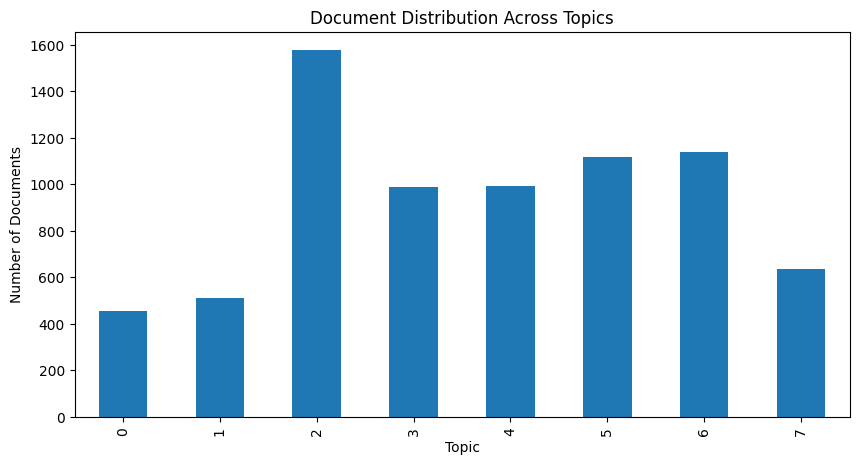

In [46]:
# Visualize topic distribution
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
df_filtered['dominant_topic'].value_counts().sort_index().plot(kind='bar')
plt.title('Document Distribution Across Topics')
plt.xlabel('Topic')
plt.ylabel('Number of Documents')
plt.show()

In [47]:
conn = sqlite3.connect("dev_ai_articles_full.sqlite")
df_filtered.to_sql("topic labeled articles", conn, if_exists="replace", index=False)
conn.close()